In [1]:

pip install pandas scikit-learn xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from xgboost import XGBClassifier



In [3]:
df = pd.read_csv("C:\\Mini Project\\diabetes_012_health_indicators_BRFSS2015.csv")


In [4]:
# ---- Add Digital Health Add-ons ----

np.random.seed(42)

# Simulated average daily steps (3000 - 15000)
df["AvgSteps"] = np.random.randint(3000, 15000, size=len(df))

# Simulated daily calorie intake (1500 - 3500)
df["DietCalories"] = np.random.randint(1500, 3500, size=len(df))

# Carb score (1 = low carb, 2 = medium, 3 = high carb)
df["CarbScore"] = np.random.choice([1, 2, 3], size=len(df))

# Check if 'Diabetes_012' column exists before processing
if 'Diabetes_012' in df.columns:
    df["Diabetic"] = df["Diabetes_012"].apply(lambda x: 1 if x == 2 else 0)
    df = df.drop("Diabetes_012", axis=1)


In [5]:
features = [
    "HighBP",
    "HighChol",
    "CholCheck",
    "BMI",
    "Smoker",
    "Stroke",
    "PhysActivity",
    "Fruits",
    "Veggies",
    "HvyAlcoholConsump",
    "Age",
    "AvgSteps",
    "DietCalories",
    "CarbScore"
]

df_model = df[features + ["Diabetic"]]


In [6]:
df.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,PhysHlth,DiffWalk,Sex,Age,Education,Income,AvgSteps,DietCalories,CarbScore,Diabetic
0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,...,15.0,1.0,0.0,9.0,4.0,3.0,10270,1870,1,0
1,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,7.0,6.0,1.0,3860,1845,1,0
2,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,...,30.0,1.0,0.0,9.0,4.0,8.0,8390,3144,3,0
3,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,11.0,3.0,6.0,8191,2895,2,0
4,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,11.0,5.0,4.0,14964,2862,2,0


In [7]:
df.isnull().sum()

HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
AvgSteps                0
DietCalories            0
CarbScore               0
Diabetic                0
dtype: int64

In [8]:
X = df_model.drop("Diabetic", axis=1)
y = df_model["Diabetic"]

print(X.columns)
print(y.value_counts())
from imblearn.over_sampling import SMOTE

# Apply SMOTE
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)


X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=42
)

Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
       'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'Age',
       'AvgSteps', 'DietCalories', 'CarbScore'],
      dtype='object')
Diabetic
0    218334
1     35346
Name: count, dtype: int64


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [10]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# XGBoost
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    eval_metric="logloss",
    random_state=42
)
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [11]:
print(y_resampled.value_counts())

Diabetic
0    218334
1    218334
Name: count, dtype: int64


In [12]:
lr_prob  = lr.predict_proba(X_test_scaled)[:,1]
rf_prob  = rf.predict_proba(X_test)[:,1]
xgb_prob = xgb.predict_proba(X_test)[:,1]

hybrid_prob = 0.3*lr_prob + 0.3*rf_prob + 0.4*xgb_prob
hybrid_pred = (hybrid_prob >= 0.5).astype(int)

print("Hybrid Accuracy:", accuracy_score(y_test, hybrid_pred))
print("Hybrid ROC-AUC:", roc_auc_score(y_test, hybrid_prob))



Hybrid Accuracy: 0.9116037282158151
Hybrid ROC-AUC: 0.9667135149484212


In [13]:
import joblib

diabetes_bundle = {
    "lr": lr,        # Logistic Regression
    "rf": rf,        # Random Forest
    "xgb": xgb,      # XGBoost
    "scaler": scaler,         # StandardScaler used for LR
    "le_dict": None,
    "features": X.columns.tolist()          # Only needed if categorical are strings
} 
# Save everything in one file
joblib.dump(diabetes_bundle, "models/diabetes.pkl")
print("Diabetes model bundle saved successfully!")

Diabetes model bundle saved successfully!


In [14]:

 def calculate_diabetes_risk(user_data_dict, sleep_hours):

    # Convert input to DataFrame
    user_df = pd.DataFrame([user_data_dict])

    # Scale for Logistic Regression
    user_scaled = scaler.transform(user_df)

    # Get model probabilities
    lr_prob  = lr.predict_proba(user_scaled)[0][1]
    rf_prob  = rf.predict_proba(user_df)[0][1]
    xgb_prob = xgb.predict_proba(user_df)[0][1]

    # Hybrid weighted probability
    base_risk = (0.3 * lr_prob) + (0.3 * rf_prob) + (0.4 * xgb_prob)

    # Sleep-based adjustment (Digital Twin logic)
    if sleep_hours < 6:
        base_risk += 0.05
    elif sleep_hours > 9:
        base_risk += 0.03

    # Keep probability in valid range
    base_risk = min(max(base_risk, 0), 1)

    return round(base_risk * 100, 2)


In [15]:
user_input = {
    "HighBP": 1,
    "HighChol": 1,
    "CholCheck": 1,
    "BMI": 32,
    "Smoker": 0,
    "Stroke": 0,
    "PhysActivity": 0,
    "Fruits": 0,
    "Veggies": 1,
    "HvyAlcoholConsump": 0,
    "Age": 9,
    "AvgSteps": 4000,
    "DietCalories": 2800,
    "CarbScore": 3
}

sleep_hours = 5 # Example sleep hours

risk_score = calculate_diabetes_risk(user_input, sleep_hours)
print("Diabetes Risk:", round(risk_score,2), "%")

Diabetes Risk: 60.79 %


In [16]:
def digital_twin_simulation(user_data, sleep_hours):

    base_risk = calculate_diabetes_risk(user_data, sleep_hours)

    print("Original Risk:", round(base_risk,2), "%")

    # Scenario 1: Increase steps
    improved_steps = user_data.copy()
    improved_steps["AvgSteps"] += 4000

    risk_steps = calculate_diabetes_risk(improved_steps, sleep_hours)
    print("If Steps Increase → Risk:", round(risk_steps,2), "%")

    # Scenario 2: Reduce carbs
    improved_diet = user_data.copy()
    improved_diet["CarbScore"] = max(1, user_data["CarbScore"] - 1)

    risk_diet = calculate_diabetes_risk(improved_diet, sleep_hours)
    print("If Carb Intake Reduced → Risk:", round(risk_diet,2), "%")

    # Scenario 3: Improve both
    combined = improved_steps.copy()
    combined["CarbScore"] = max(1, user_data["CarbScore"] - 1)

    risk_combined = calculate_diabetes_risk(combined, sleep_hours)
    print("If Both Improved → Risk:", round(risk_combined,2), "%")

In [17]:
digital_twin_simulation(user_input, sleep_hours)

Original Risk: 60.79 %
If Steps Increase → Risk: 50.67 %
If Carb Intake Reduced → Risk: 62.18 %
If Both Improved → Risk: 56.67 %


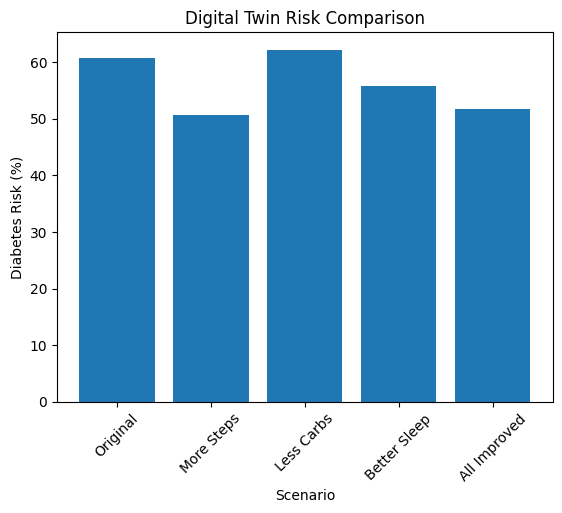

In [18]:
import matplotlib.pyplot as plt

# Calculate risks
original_risk = calculate_diabetes_risk(user_input, sleep_hours)

improved_steps = user_input.copy()
improved_steps["AvgSteps"] += 4000
risk_steps = calculate_diabetes_risk(improved_steps, sleep_hours)

improved_diet = user_input.copy()
improved_diet["CarbScore"] = max(1, user_input["CarbScore"] - 1)
risk_diet = calculate_diabetes_risk(improved_diet, sleep_hours)

better_sleep = 7
risk_sleep = calculate_diabetes_risk(user_input, better_sleep)

combined = improved_steps.copy()
combined["CarbScore"] = max(1, user_input["CarbScore"] - 1)
risk_combined = calculate_diabetes_risk(combined, better_sleep)

# Labels and values
labels = [
    "Original",
    "More Steps",
    "Less Carbs",
    "Better Sleep",
    "All Improved"
]

values = [
    original_risk,
    risk_steps,
    risk_diet,
    risk_sleep,
    risk_combined
]

# Plot
plt.figure()
plt.bar(labels, values)
plt.xlabel("Scenario")
plt.ylabel("Diabetes Risk (%)")
plt.title("Digital Twin Risk Comparison")
plt.xticks(rotation=45)
plt.show()
